In [ ]:
import numpy as np
import random

class EcoDrivingEnv:
    def __init__(self):
      # The Track Topography: 0 = Downhill_bend, 1 = Flat, 2 = Uphill_bend
        self.track = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2]
        #[1, 1, 1, 0, 0, 1, 1, 3, 3, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 3, 3, 1, 1, 1] Old array
        self.track_length = len(self.track)

        self.num_speed_states = 4
        self.num_track_states = 3
        self.num_actions = 4

        self.reset()

    def reset(self):
        self.position = 0
        self.speed = 0
        self.prev_action = 0
        return self.get_state()

    def get_state(self):
        t_current = self.track[self.position] if self.position < self.track_length else self.track[0]
        t_next = self.track[(self.position + 1) % self.track_length]
        t_next_next = self.track[(self.position + 2) % self.track_length]

        return (self.speed, t_current, t_next, t_next_next, self.prev_action)

    def step(self, action):
        reward = -3
        done = False
        current_terrain = self.track[self.position]

        next_terrain = self.track[(self.position + 1) % self.track_length]
        next_next_terrain = self.track[(self.position + 2) % self.track_length]

        # Aplicando fisica
        if action == 3: # BRAKE
            self.speed -= 2
            reward -= 200

        elif action == 2: # PULSE
            self.speed += 1

            # Acelerar quando o carro já está rápido (Velocidade 3) gasta mais energia!
            if self.speed == 3:
                reward -= 15
            else:
                reward -= 5

             # Ataca a colina
            if next_terrain == 2:
                if self.speed == 3:
                    reward += 200

            # Não acelere na curva
            if current_terrain == 0:
                reward -= 150
            if current_terrain == 2:
                reward -= 500

        elif action == 1: # MAINTAIN
            reward -= 15
            if current_terrain == 2 or current_terrain == 0:
                reward -= 500

        else: # GLIDE
            self.speed = max(0, self.speed - 1)
            reward += 20

            # Se a ação atual é GLIDE (0) e a ação anterior também foi GLIDE (0)...
            if self.prev_action == 0:
                reward += 15  # Prêmio extra por manter o motor desligado consecutivamente!

            # recompensa por não usar motor nas curvas
            if current_terrain in [0, 2]:
                reward += 200



        # Gravidade
        if current_terrain == 0:   # DOWNHILL_bend (+1 speed)
            self.speed += 1
        elif current_terrain == 2: # UPHILL_bend (-1 speed)
            self.speed -= 1


        self.speed = max(0, min(3, self.speed))

        # Recompensa por velocidades
        if self.speed == 3:
            reward += 20
            if next_terrain == 2:
                reward += 200

        elif self.speed == 2:
            reward += 4
            if next_terrain == 2:
                reward -= 20
        elif self.speed == 1:
            reward += 2
            if next_terrain == 2:
                reward -= 80
        elif self.speed == 0:
            reward += 4
            if current_terrain == 0:
                reward += 200  # Smart Stall
            elif current_terrain == 2 or next_terrain == 2:
                reward -= 200  # FATAL STALL
                done = True
            else:
                reward -= 50  #Bad Stall

        # Move pra pocima posição
        self.position += 1

        # Analisa limites da pista
        if self.position >= self.track_length:

            if self.speed == 0:
                reward += 1000  # Super Bônus. Terminou a volta perfeitamente em Stall
            else:
                # Punição progressiva, quanto mais rápido ele cruzar a chegada, pior.
                reward -= (self.speed * 100)
            done = True
        else:
            if self.track[self.position] == 2:
                if self.speed == 1:
                    reward += 20
                elif self.speed == 2:
                    reward += 10
                elif self.speed == 0:
                    reward -= 500
                    done = True
                elif self.speed == 3 :
                    reward += 50
            elif self.track[self.position] == 0:
                if self.speed == 0:
                    reward += 30
                elif self.speed == 1:
                    reward += 20
                elif self.speed == 2:
                    reward += 10
                elif self.speed == 3:
                    reward -= 500
                    done = True

        self.prev_action = action
        return self.get_state(), reward, done

# Teste
env = EcoDrivingEnv()
print("Environment upgraded.")

Environment upgraded.


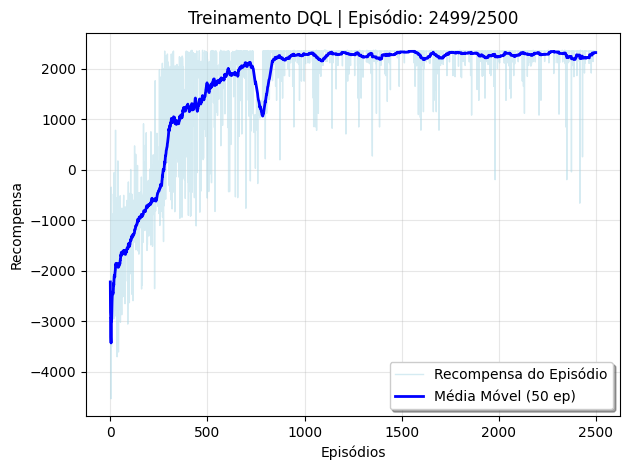

Treinamento Concluído! Melhor pontuação atingida: 2369


In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt
from IPython.display import clear_output
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque

#  One-Hot Encoding
# Expande as 5 variáveis em uma matriz de 17 posições binárias (0 ou 1)
def state_to_features(state):
    speed, t_curr, t_next, t_next_next, prev_act = state

    f_speed = [1 if speed == i else 0 for i in range(4)]
    f_tc = [1 if t_curr == i else 0 for i in range(3)]
    f_tn = [1 if t_next == i else 0 for i in range(3)]
    f_tnn = [1 if t_next_next == i else 0 for i in range(3)]
    f_prev = [1 if prev_act == i else 0 for i in range(4)]

    # Retorna o array de 17 posições normalizado
    return np.array(f_speed + f_tc + f_tn + f_tnn + f_prev, dtype=np.float32)

# Definição da Rede Neural
class DQN(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(state_dim, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, action_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

# Buffer de Experiência
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        states, actions, rewards, next_states, dones = zip(*random.sample(self.buffer, batch_size))

        feat_states = [state_to_features(s) for s in states]
        feat_next_states = [state_to_features(s) for s in next_states]

        return (torch.FloatTensor(np.array(feat_states)),
                torch.LongTensor(actions),
                torch.FloatTensor(rewards),
                torch.FloatTensor(np.array(feat_next_states)),
                torch.FloatTensor(dones))

    def __len__(self):
        return len(self.buffer)

# Hyperparâmetros do Deep Q-Learning
state_dim = 17
action_dim = env.num_actions
batch_size = 64
gamma = 0.95
epsilon_start = 1.0
epsilon_decay = 0.995
min_epsilon = 0.01
learning_rate = 0.0005
episodes = 2500
target_update = 10

policy_net = DQN(state_dim, action_dim)
target_net = DQN(state_dim, action_dim)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=learning_rate)
memory = ReplayBuffer(10000)

avg_rewards_per_episode = []
smoothed_avg_rewards = []
best_reward = -float('inf')
best_policy_state = None

plt.ion()
plt.figure(figsize=(10, 5))
epsilon = epsilon_start

# O Loop de Treinamento
for episode in range(episodes):
    state = env.reset()
    # Converte o estado inicial para binário
    state_tensor = torch.FloatTensor(state_to_features(state)).unsqueeze(0)
    total_reward = 0
    done = False

    while not done:
        if random.random() < epsilon:
            action = random.choice([0, 1, 2, 3])
        else:
            with torch.no_grad():
                q_values = policy_net(state_tensor)
                action = q_values.argmax().item()

        next_state, reward, done = env.step(action)
        # Converte o próximo estado para binário
        next_state_tensor = torch.FloatTensor(state_to_features(next_state)).unsqueeze(0)

        # Guarda na memória o estado original
        memory.push(state, action, reward, next_state, done)

        state = next_state
        state_tensor = next_state_tensor
        total_reward += reward

        if len(memory) >= batch_size:
            batch_states, batch_actions, batch_rewards, batch_next_states, batch_dones = memory.sample(batch_size)

            current_q_values = policy_net(batch_states).gather(1, batch_actions.unsqueeze(1)).squeeze(1)

            with torch.no_grad():
                max_next_q_values = target_net(batch_next_states).max(1)[0]
                expected_q_values = batch_rewards + (gamma * max_next_q_values * (1 - batch_dones))

            # Huber Loss no lugar de MSE
            loss = F.smooth_l1_loss(current_q_values, expected_q_values)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    epsilon = max(min_epsilon, epsilon * epsilon_decay)
    avg_rewards_per_episode.append(total_reward)

    if total_reward >= best_reward and epsilon < 0.02:
        best_reward = total_reward
        best_policy_state = policy_net.state_dict().copy()

    if episode % target_update == 0:
        target_net.load_state_dict(policy_net.state_dict())

    window_size = 50
    smoothed_avg_rewards.append(np.mean(avg_rewards_per_episode[-window_size:]))

    if episode % 20 == 0 or episode == episodes - 1:
        clear_output(wait=True)
        plt.clf()
        plt.plot(avg_rewards_per_episode, color='lightblue', alpha=0.5, linewidth=1, label='Recompensa do Episódio')
        plt.plot(smoothed_avg_rewards, color='blue', linewidth=2, label=f'Média Móvel ({window_size} ep)')
        plt.title(f"Treinamento DQL | Episódio: {episode}/{episodes}")
        plt.xlabel("Episódios")
        plt.ylabel("Recompensa")
        plt.legend(loc='lower right', fancybox=True, shadow=True)
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
        plt.pause(0.001)

plt.ioff()
print(f"Treinamento Concluído! Melhor pontuação atingida: {best_reward}")



```
# This is formatted as code
```

Path map

Capsule


Telemetria da Corrida
Passo 01 | Pista: Plano   | Vel Atual: Stall    -> Ação: PULSE
Passo 02 | Pista: Plano   | Vel Atual: Middle 1 -> Ação: PULSE
Passo 03 | Pista: Plano   | Vel Atual: Middle 2 -> Ação: PULSE
Passo 04 | Pista: Plano   | Vel Atual: High     -> Ação: GLIDE
Passo 05 | Pista: Plano   | Vel Atual: Middle 2 -> Ação: GLIDE
Passo 06 | Pista: Plano   | Vel Atual: Middle 1 -> Ação: PULSE
Passo 07 | Pista: Plano   | Vel Atual: Middle 2 -> Ação: PULSE
Passo 08 | Pista: Plano   | Vel Atual: High     -> Ação: GLIDE
Passo 09 | Pista: Plano   | Vel Atual: Middle 2 -> Ação: GLIDE
Passo 10 | Pista: Plano   | Vel Atual: Middle 1 -> Ação: GLIDE
Passo 11 | Pista: Declive | Vel Atual: Stall    -> Ação: GLIDE
Passo 12 | Pista: Declive | Vel Atual: Middle 1 -> Ação: GLIDE
Passo 13 | Pista: Plano   | Vel Atual: Middle 1 -> Ação: PULSE
Passo 14 | Pista: Plano   | Vel Atual: Middle 2 -> Ação: PULSE
Passo 15 | Pista: Plano   | Vel Atual: High     -> Ação: GLIDE
Passo 16 | Pista: Plano   | Vel 

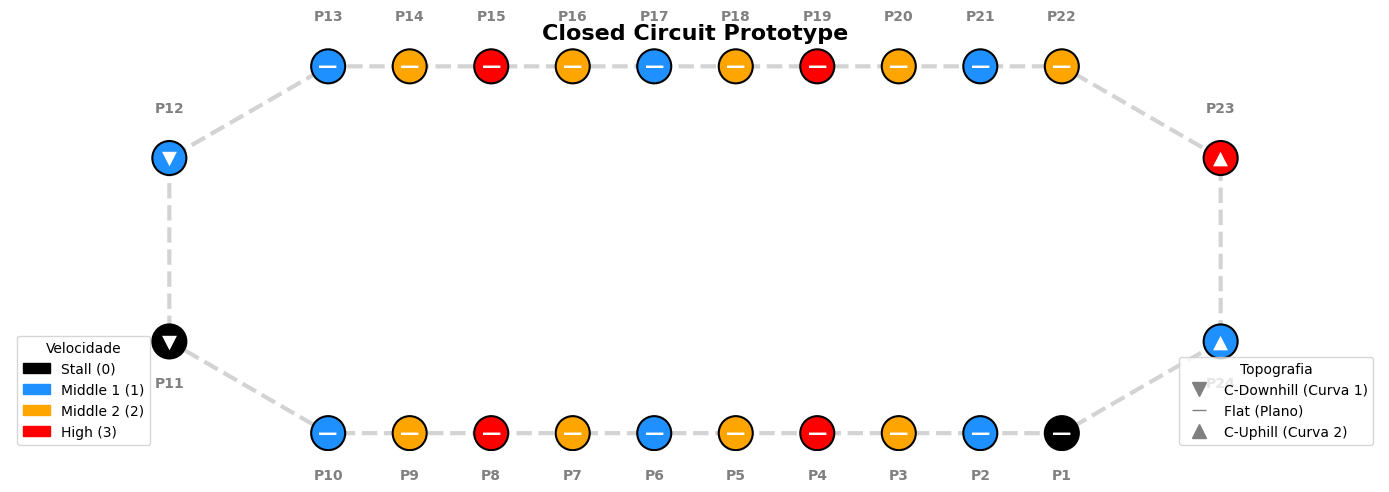

In [ ]:
# Telemetria e Mapeamento do Circuito
import matplotlib.pyplot as plt
import numpy as np

policy_net.load_state_dict(best_policy_state)
policy_net.eval() # Trava a rede em modo de avaliação (desliga comportamentos de treino)

print("\nTelemetria da Corrida")
state = env.reset()
done = False
lap_reward = 0
step_count = 0

# SYMMETRICAL CAPSULE
def generate_capsule_coords():
    comprimento = 8
    raio = 2
    x_c, y_c = [], []

    # Reta Inferior (10 nodes: P1 to P10) - Começa na direita e vai para a esquerda
    for x in np.linspace(comprimento, 0, 10):
        x_c.append(x)
        y_c.append(-raio)

    # Curva Esquerda (2 nodes: P11 and P12)
    for theta in [-5*np.pi/6, -7*np.pi/6]:
        x_c.append(0 + raio * np.cos(theta))
        y_c.append(raio * np.sin(theta))

    # Reta Superior (10 nodes: P13 to P22) - Começa na esquerda e vai para a direita
    for x in np.linspace(0, comprimento, 10):
        x_c.append(x)
        y_c.append(raio)

    # Curva Direita (2 nodes: P23 and P24)
    for theta in [np.pi/6, -np.pi/6]:
        x_c.append(comprimento + raio * np.cos(theta))
        y_c.append(raio * np.sin(theta))

    return x_c, y_c

# Carrega os 24 nodos
x_coords, y_coords = generate_capsule_coords()

history_x = []
history_y = []
history_colors = []
history_topo = []

speed_colors = {0: 'black', 1: 'dodgerblue', 2: 'orange', 3: 'red'}
topo_symbols = {0: '▼', 1: '—', 2: '▲', 3: '⟳'}

# Dicionários de nomes (Atenção aos nomes em português para o relatório da SBA!)
slope_names = ["Declive", "Plano", "Aclive", "Curva"]
speed_names = ["Stall", "Middle 1", "Middle 2", "High"]
action_names = ["GLIDE", "MAINTAIN", "PULSE", "BRAKE"]

while not done and step_count < env.track_length:
    speed, t_curr, t_next, t_next_next, prev_act = state

    # Passando as 5 variáveis para a Q-Table
    #action = np.argmax(q_table[speed, t_curr, t_next, t_next_next, prev_act])
    state_tensor = torch.FloatTensor(state_to_features(state)).unsqueeze(0)
    with torch.no_grad():
        # Passamos o estado de 17 variáveis para a rede neural
        action = policy_net(state_tensor).argmax().item()

    # Executa a ação no ambiente e pega o novo estado
    next_state, reward, done = env.step(action)

    current_terrain_val = env.track[env.position-1]
    current_terrain_name = slope_names[current_terrain_val]

    print(f"Passo {step_count+1:02d} | Pista: {current_terrain_name:<7} | Vel Atual: {speed_names[speed]:<8} -> Ação: {action_names[action]}")

    history_x.append(x_coords[step_count])
    history_y.append(y_coords[step_count])
    history_colors.append(speed_colors[speed])
    history_topo.append(topo_symbols[current_terrain_val])

    # O próximo estado agora também carrega a prev_act
    state = next_state
    lap_reward += reward
    step_count += 1

print(f"\nPontuação Final da Corrida: {lap_reward} pontos")

# Desenhando o Mapa (Matplotlib)
plt.figure(figsize=(14, 5))

plot_x = list(history_x) + [history_x[0]]
plot_y = list(history_y) + [history_y[0]]
plt.plot(plot_x, plot_y, color='lightgray', linestyle='--', linewidth=3, zorder=1)

# Plota
plt.scatter(history_x, history_y, c=history_colors, s=600, zorder=2, edgecolors='black', linewidths=1.5)


for i in range(len(history_x)):
    y_offset = 0.5 if y_coords[i] >= 0 else -0.5
    plt.text(history_x[i], y_coords[i] + y_offset, f"P{i+1}", fontsize=10, ha='center', fontweight='bold', color='gray')

    plt.text(history_x[i], y_coords[i], history_topo[i], fontsize=14, ha='center', va='center', color='white', fontweight='bold')

plt.title("Closed Circuit Prototype", fontsize=16, fontweight='bold')
plt.axis('equal')
plt.axis('off')

import matplotlib.patches as mpatches
import matplotlib.lines as mlines

speed_patches = [
    mpatches.Patch(color='black', label='Stall (0)'),
    mpatches.Patch(color='dodgerblue', label='Middle 1 (1)'),
    mpatches.Patch(color='orange', label='Middle 2 (2)'),
    mpatches.Patch(color='red', label='High (3)')
]
legend1 = plt.legend(handles=speed_patches, loc='lower left', title="Velocidade")

topo_patches = [
    mlines.Line2D([], [], color='white', marker='v', markersize=10, markerfacecolor='gray', markeredgecolor='gray', label='C-Downhill (Curva 1)'),
    mlines.Line2D([], [], color='white', marker='_', markersize=10, markerfacecolor='gray', markeredgecolor='gray', label='Flat (Plano)'),
    mlines.Line2D([], [], color='white', marker='^', markersize=10, markerfacecolor='gray', markeredgecolor='gray', label='C-Uphill (Curva 2)'),
]
plt.legend(handles=topo_patches, loc='lower right', title="Topografia")

plt.gca().add_artist(legend1)
plt.tight_layout()
plt.show()

Brain context